# Reuse Patterns: QKernel Composition and Composite Gates

As circuits grow, you want to avoid copy-pasting gate sequences. Qamomile offers two complementary reuse mechanisms:

1. **Helper QKernel** — call one `@qkernel` from another, like normal
   function composition.
2. **`@composite_gate`** — promote a qkernel to a **named gate**
   with customizable settings that appears as a single box in diagrams.

There is also a third pattern for top-down design:

3. **Stub composite gate** — a gate with no implementation body, used for
   resource estimation.
   For example, if you are designing a Grover search algorithm,
   you know the oracle will use ~40 T-gates, but you haven't implemented it yet.
   A stub composite gate lets you estimate the total cost of the algorithm
   without the full oracle implementation.

In [1]:
# Install the latest Qamomile through pip!
# !pip install qamomile

In [2]:
import qamomile.circuit as qmc
from qamomile.circuit.ir.operation.composite_gate import ResourceMetadata
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## Pattern 1: Helper QKernel

Any `@qkernel` function can be called from another `@qkernel`. The transpiler inlines the call — the result is a flat circuit.

In [3]:
@qmc.qkernel
def entangle_once(q0: qmc.Qubit, q1: qmc.Qubit) -> tuple[qmc.Qubit, qmc.Qubit]:
    q0, q1 = qmc.cx(q0, q1)
    return q0, q1


@qmc.qkernel
def ghz_with_helper(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q[0] = qmc.h(q[0])

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = entangle_once(q[i], q[i + 1])

    return qmc.measure(q)

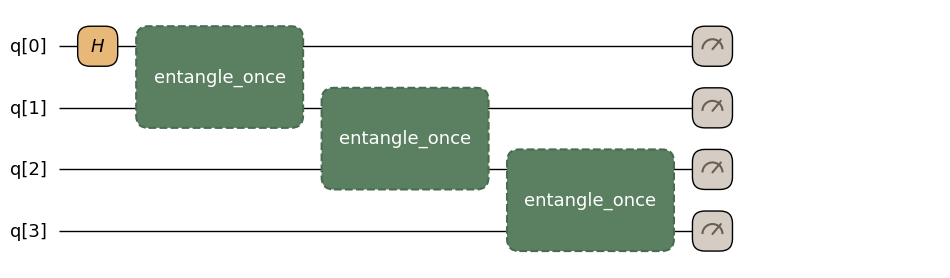

In [4]:
ghz_with_helper.draw(n=4, fold_loops=False)

In [5]:
result = (
    transpiler.transpile(ghz_with_helper, bindings={"n": 4})
    .sample(
        transpiler.executor(),
        shots=128,
    )
    .result()
)
print("GHZ result:", result.results)

GHZ result: [((1, 1, 1, 1), 66), ((0, 0, 0, 0), 62)]


The helper `entangle_once` keeps the call site readable. In the transpiled circuit, it is inlined — you see individual CX gates, not a sub-block.

In [6]:
qc = transpiler.to_circuit(ghz_with_helper, bindings={"n": 4})
print(qc.draw())

     ┌───┐          ┌─┐              
q_0: ┤ H ├──■───────┤M├──────────────
     └───┘┌─┴─┐     └╥┘     ┌─┐      
q_1: ─────┤ X ├──■───╫──────┤M├──────
          └───┘┌─┴─┐ ║      └╥┘┌─┐   
q_2: ──────────┤ X ├─╫───■───╫─┤M├───
               └───┘ ║ ┌─┴─┐ ║ └╥┘┌─┐
q_3: ────────────────╫─┤ X ├─╫──╫─┤M├
                     ║ └───┘ ║  ║ └╥┘
c: 4/════════════════╩═══════╩══╩══╩═
                     0       1  2  3 


## Pattern 2: `@composite_gate`

When you want a reusable block to appear as a **named box** in circuit diagrams, promote it with `@composite_gate`. Also, as a more advanced use case, making it a composite gate allows you to give it custom settings such as giving it multiple ways of implementation.

Stack `@composite_gate(name="...")` on top of `@qkernel`:

In [7]:
@qmc.composite_gate(name="entangle")
@qmc.qkernel
def entangle_link(q0: qmc.Qubit, q1: qmc.Qubit) -> tuple[qmc.Qubit, qmc.Qubit]:
    q0, q1 = qmc.cx(q0, q1)
    return q0, q1


@qmc.qkernel
def ghz_with_composite(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q[0] = qmc.h(q[0])

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = entangle_link(q[i], q[i + 1])

    return qmc.measure(q)

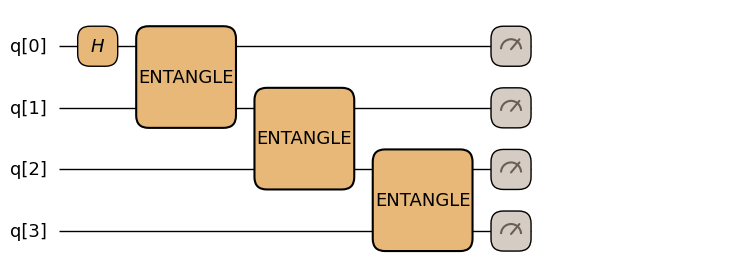

In [8]:
ghz_with_composite.draw(n=4, fold_loops=False)

### When to use which?

| Pattern | Appears in `draw()` | Use when |
|---------|---------------------|------|
| Helper `@qkernel` | Inlined (flat) | Code organization |
| `@composite_gate` | Named box | Domain-level abstraction/advanced settings |

## Pattern 3: Stub Composite Gate for Top-Down Design

Sometimes you want to design an algorithm's structure before implementing every sub-component. A **stub composite gate** has no implementation body — just a name, qubit count, and optional resource metadata.

This lets you estimate the cost of the overall algorithm while the oracle or sub-routine is still under development.

To use a stub composite gate, specify `stub=True` in the `@composite_gate` decorator. At the same time, you can also give it resource information as `ResourceMetadata`.

In [9]:
@qmc.composite_gate(
    stub=True,
    name="oracle",
    num_qubits=3,
    resource_metadata=ResourceMetadata(
        query_complexity=1,
        t_gates=40,
    ),
)
def oracle_box():
    pass


@qmc.qkernel
def algorithm_skeleton() -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(3, name="q")
    for i in qmc.range(3):
        q[i] = qmc.h(q[i])

    q[0], q[1], q[2] = oracle_box(q[0], q[1], q[2])
    return q

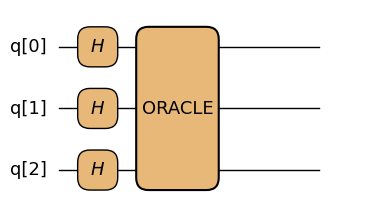

In [10]:
algorithm_skeleton.draw(fold_loops=False)

### Resource Estimation for QKernels that Include Stub Gates

`estimate_resources()` can analyze a full qkernel even when oracle internals are unknown. Known scaffold gates are counted directly, and stub components are tracked through `est.gates.oracle_calls` / `est.gates.oracle_queries`.

In [11]:
est = algorithm_skeleton.estimate_resources().simplify()
print("qubits:", est.qubits)
print("total gates:", est.gates.total)

qubits: 3
total gates: 3


Next, we build a qkernel that mixes ordinary gates with multiple stub oracles.

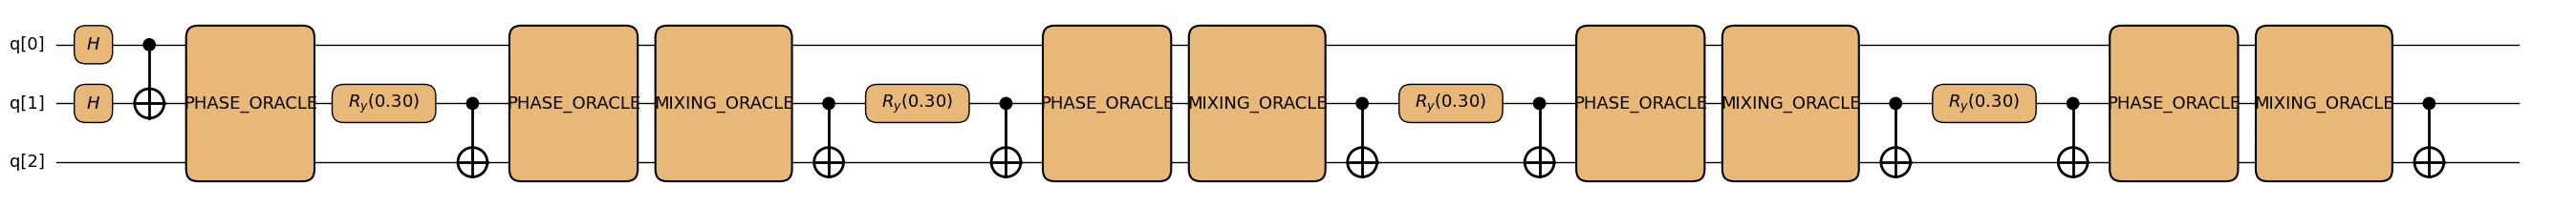

In [12]:
@qmc.composite_gate(
    stub=True,
    name="phase_oracle",
    num_qubits=3,
    resource_metadata=ResourceMetadata(query_complexity=2),
)
def phase_oracle():
    pass


@qmc.composite_gate(
    stub=True,
    name="mixing_oracle",
    num_qubits=3,
    resource_metadata=ResourceMetadata(query_complexity=1),
)
def mixing_oracle():
    pass


@qmc.qkernel
def iterative_oracle_skeleton(rounds: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(3, name="q")

    # Known scaffold (non-oracle) gates
    q[0] = qmc.h(q[0])
    q[1] = qmc.h(q[1])
    q[0], q[1] = qmc.cx(q[0], q[1])

    # One oracle call outside the loop
    q[0], q[1], q[2] = phase_oracle(q[0], q[1], q[2])

    # Each round mixes known gates and unknown oracle blocks
    for i in qmc.range(rounds):
        q[1] = qmc.ry(q[1], 0.3)
        q[1], q[2] = qmc.cx(q[1], q[2])
        q[0], q[1], q[2] = phase_oracle(q[0], q[1], q[2])
        q[0], q[1], q[2] = mixing_oracle(q[0], q[1], q[2])
        q[1], q[2] = qmc.cx(q[1], q[2])

    return q


iterative_oracle_skeleton.draw(rounds=4, fold_loops=False)

In [13]:
oracle_est = iterative_oracle_skeleton.estimate_resources().simplify()
print("total gates:", oracle_est.gates.total)
print("two-qubit gates:", oracle_est.gates.two_qubit)
print("oracle_calls:", oracle_est.gates.oracle_calls)
print("oracle_queries:", oracle_est.gates.oracle_queries)

total gates: 3*rounds + 3
two-qubit gates: 2*rounds + 1
oracle_calls: {'phase_oracle': rounds + 1, 'mixing_oracle': rounds}
oracle_queries: {'phase_oracle': 2*rounds + 2, 'mixing_oracle': rounds}


Substitute a concrete value for `rounds` to get numeric counts:

In [14]:
oracle_est_4 = oracle_est.substitute(rounds=4)
print("oracle_calls (rounds=4):", oracle_est_4.gates.oracle_calls)
print("oracle_queries (rounds=4):", oracle_est_4.gates.oracle_queries)

oracle_calls (rounds=4): {'phase_oracle': 5, 'mixing_oracle': 4}
oracle_queries (rounds=4): {'phase_oracle': 10, 'mixing_oracle': 4}


In this example, resource analysis works without oracle internals: known gates contribute to `total` / `two_qubit`, while unknown oracle blocks are tracked as `oracle_calls` (for example, `{'phase_oracle': rounds + 1, 'mixing_oracle': rounds}`) and `oracle_queries` (weighted by each stub's `query_complexity`).

This lets you reason about algorithm-level costs (such as qubit count, oracle queries) before committing to a full decomposition.

## Summary

- **Helper `@qkernel`**: call one qkernel from another for code reuse.
  The transpiler inlines the call into a flat circuit.
- **`@composite_gate`**: gives a qkernel a named identity visible in
  diagrams. Stack `@composite_gate` on top of `@qkernel`.
- **Stub composite gate**: `stub=True` with `ResourceMetadata` for top-down
  design and resource estimation without a full implementation.
- **`est.gates.oracle_calls`**: even when oracle internals are unknown, this reports per-oracle call counts as a dict (including symbolic call counts).